Validation Error: 11 validation errors for TestConfig
t_min_use
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/float_parsing
t_max_use
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/float_parsing
t_min_test
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/float_parsing
t_max_test
  Input should be a valid number, unable to parse string as a number [type=float_parsing, input_value='', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/float_parsing
dwell_max_hr
  Input should be a valid number, unable to parse string as a number [t

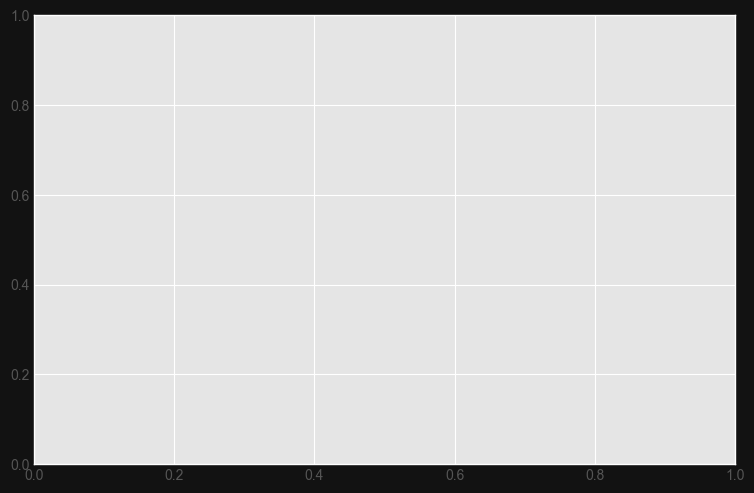

In [22]:
import customtkinter as ctk
from pydantic import BaseModel, Field, PositiveFloat
from typing import Literal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np

# Styling for modern dashboard look
plt.style.use('ggplot')

class TestConfig(BaseModel):
    t_min_use: float
    t_max_use: float
    t_min_test: float
    t_max_test: float
    dwell_max_hr: float = Field(ge=0)
    dwell_min_hr: float = Field(ge=0)
    ramp_up_rate: PositiveFloat
    ramp_down_rate: PositiveFloat
    m_exponent: PositiveFloat
    time_value: PositiveFloat
    time_unit: Literal["Years", "Months", "Days"]
    cycles_per_day: PositiveFloat

    @property
    def time_in_years(self) -> float:
        multipliers = {"Years": 1.0, "Months": 1/12, "Days": 1/365}
        return self.time_value * multipliers[self.time_unit]

class ReliabilityEngine:
    @staticmethod
    def calculate_metrics(config: TestConfig) -> dict:
        delta_t_use = config.t_max_use - config.t_min_use
        delta_t_test = config.t_max_test - config.t_min_test
        af = (delta_t_test / delta_t_use) ** config.m_exponent
        
        cycles_field = config.time_in_years * 365 * config.cycles_per_day
        cycles_test = cycles_field / af
        
        r_up = (delta_t_test / config.ramp_up_rate) / 60
        r_down = (delta_t_test / config.ramp_down_rate) / 60
        total_hr = (config.dwell_max_hr + config.dwell_min_hr + r_up + r_down) * cycles_test
        
        return {
            "af": af,
            "cycles_field": int(cycles_field),
            "cycles_test": int(cycles_test),
            "total_hr": round(total_hr, 1),
            "total_days": round(total_hr / 24, 1)
        }

    @staticmethod
    def get_plot_data(config: TestConfig, mode: str, cycles_test: int):
        delta_t = config.t_max_test - config.t_min_test
        r_up = (delta_t / config.ramp_up_rate)
        d_max = config.dwell_max_hr * 60
        r_down = (delta_t / config.ramp_down_rate)
        d_min = config.dwell_min_hr * 60
        
        # Base cycle coords
        single_t = np.array([0, r_up, r_up + d_max, r_up + d_max + r_down, r_up + d_max + r_down + d_min])
        single_temp = np.array([config.t_min_test, config.t_max_test, config.t_max_test, config.t_min_test, config.t_min_test])
        
        if mode == "Single Cycle":
            return single_t, single_temp
        else:
            # Generate first 5 and last 5 for performance if cycles are high, 
            # but for a simulation we'll show a sample of 5 cycles.
            num_show = min(5, int(cycles_test))
            full_t, full_temp = [], []
            for i in range(num_show):
                full_t.extend(single_t + (i * single_t[-1]))
                full_temp.extend(single_temp)
            return np.array(full_t), np.array(full_temp)

class StatCard(ctk.CTkFrame):
    """A reusable component for attractive metric display."""
    def __init__(self, master, title, value, unit="", color="#1f77b4"):
        super().__init__(master, fg_color="#2b2b2b", corner_radius=10, border_width=1, border_color="#3d3d3d")
        self.lbl_title = ctk.CTkLabel(self, text=title, font=("Arial", 12), text_color="#aaaaaa")
        self.lbl_title.pack(pady=(10, 0))
        self.lbl_val = ctk.CTkLabel(self, text=value, font=("Arial", 22, "bold"), text_color=color)
        self.lbl_val.pack(pady=(0, 5))
        self.lbl_unit = ctk.CTkLabel(self, text=unit, font=("Arial", 10), text_color="#666666")
        self.lbl_unit.pack(pady=(0, 10))

    def update_val(self, val):
        self.lbl_val.configure(text=str(val))

class App(ctk.CTk):
    def __init__(self):
        super().__init__()
        self.title("Reliability Design Studio")
        self.geometry("1280x800")
        ctk.set_appearance_mode("dark")
        
        self.grid_columnconfigure(0, weight=0) # Sidebar
        self.grid_columnconfigure(1, weight=1) # Main Content
        self.grid_rowconfigure(0, weight=1)

        self.inputs = {}
        self._setup_ui()

    def _setup_ui(self):
        # --- Sidebar ---
        sidebar = ctk.CTkScrollableFrame(self, width=320, corner_radius=0, fg_color="#1a1a1a")
        sidebar.grid(row=0, column=0, sticky="nsew", padx=0, pady=0)
        
        ctk.CTkLabel(sidebar, text="THERMAL AGING DUTY CYCLE", font=("Arial", 20, "bold"), text_color="#3a7ebf").pack(pady=20)
        
        input_groups = [
            ("Field Environment", [("Tmin (Field)", "t_min_use"), ("Tmax (Field)", "t_max_use")]),
            ("Test Profile", [("Tmin (test)", "t_min_test"), ("Tmax (test)", "t_max_test"), 
                              ("Ramp Up (degC/min)    ", "ramp_up_rate"), ("RampDown(degC/min)", "ramp_down_rate")]),
            ("Dwell Settings", [("Dwell Max (Hr)", "dwell_max_hr"), ("Dwell Min (Hr)", "dwell_min_hr")]),
            ("Parameters", [("m exponent", "m_exponent"), ("Cycles/Day", "cycles_per_day")])
        ]

        for group_name, fields in input_groups:
            ctk.CTkLabel(sidebar, text=group_name, font=("Arial", 12, "bold"), text_color="#555555").pack(anchor="w", padx=20, pady=(15, 5))
            for label, key in fields:
                f = ctk.CTkFrame(sidebar, fg_color="transparent")
                f.pack(fill="x", padx=20)
                ctk.CTkLabel(f, text=label, width=100, anchor="w").pack(side="left")
                entry = ctk.CTkEntry(f, height=28)
                entry.pack(side="right", fill="x", expand=True, pady=2)
                self.inputs[key] = entry

        # Duration logic
        ctk.CTkLabel(sidebar, text="Life Requirement", font=("Arial", 12, "bold"), text_color="#555555").pack(anchor="w", padx=20, pady=(15, 5))
        dur_f = ctk.CTkFrame(sidebar, fg_color="transparent")
        dur_f.pack(fill="x", padx=20)
        self.time_val = ctk.CTkEntry(dur_f, width=80)
        self.time_val.pack(side="left")
        self.time_unit = ctk.CTkOptionMenu(dur_f, values=["Years", "Months", "Days"], height=28)
        self.time_unit.pack(side="right", fill="x", expand=True, padx=(5, 0))

        self.btn = ctk.CTkButton(sidebar, text="RUN ANALYSIS", command=self.run, fg_color="#3a7ebf", hover_color="#2d6194", height=40)
        self.btn.pack(pady=30, padx=20, fill="x")

        # --- Main Content ---
        main = ctk.CTkFrame(self, fg_color="#121212", corner_radius=0)
        main.grid(row=0, column=1, sticky="nsew")

        # Stats Row
        self.stats_row = ctk.CTkFrame(main, fg_color="transparent")
        self.stats_row.pack(fill="x", padx=20, pady=20)
        
        self.cards = {
            "af": StatCard(self.stats_row, "Acceleration Factor", "-", "AF Ratio", "#ff9500"),
            "field": StatCard(self.stats_row, "Field Cycles", "-", "Required", "#3a7ebf"),
            "test": StatCard(self.stats_row, "Test Cycles", "-", "Simulated", "#3a7ebf"),
            "days": StatCard(self.stats_row, "Total Duration", "-", "Days", "#4cd964")
        }
        for card in self.cards.values():
            card.pack(side="left", fill="both", expand=True, padx=5)

        # Plot Controls
        ctrl_f = ctk.CTkFrame(main, fg_color="transparent")
        ctrl_f.pack(fill="x", padx=25)
        self.view_mode = ctk.CTkSegmentedButton(ctrl_f, values=["Single Cycle", "Complete View"], command=lambda _: self.run())
        self.view_mode.set("Single Cycle")
        self.view_mode.pack(side="right")

        # Plot Area
        self.fig, self.ax = plt.subplots(figsize=(8, 4), facecolor='#121212')
        self.canvas = FigureCanvasTkAgg(self.fig, master=main)
        self.canvas.get_tk_widget().pack(fill="both", expand=True, padx=20, pady=20)

    def run(self):
        try:
            data = {k: v.get() for k, v in self.inputs.items()}
            data.update({"time_value": self.time_val.get(), "time_unit": self.time_unit.get()})
            config = TestConfig(**data)
            metrics = ReliabilityEngine.calculate_metrics(config)
            
            # Update Cards
            self.cards["af"].update_val(f"{metrics['af']:.2f}x")
            self.cards["field"].update_val(f"{metrics['cycles_field']:,}")
            self.cards["test"].update_val(f"{metrics['cycles_test']:,}")
            self.cards["days"].update_val(f"{metrics['total_days']:,}")

            # Update Plot
            t, temp = ReliabilityEngine.get_plot_data(config, self.view_mode.get(), metrics['cycles_test'])
            self.ax.clear()
            self.ax.set_facecolor('#F5F5F5')
            self.ax.plot(t, temp, color="#3a7ebf", linewidth=2, marker='o' if "Single" in self.view_mode.get() else None)
            self.ax.fill_between(t, temp, min(temp)-10, color="#3a7ebf", alpha=0.2)
            self.ax.set_title(f"Thermal Profile: {self.view_mode.get()}", color="white", pad=20)
            self.ax.tick_params(colors='white')
            for spine in self.ax.spines.values(): spine.set_color('#444444')
            self.ax.set_xlabel("Time (Minutes)", color="#888888")
            self.ax.set_ylabel("Temp (°C)", color="#888888")
            
            self.fig.tight_layout()
            self.canvas.draw()
            
        except Exception as e:
            print(f"Validation Error: {e}")

if __name__ == "__main__":
    app = App()
    app.mainloop()

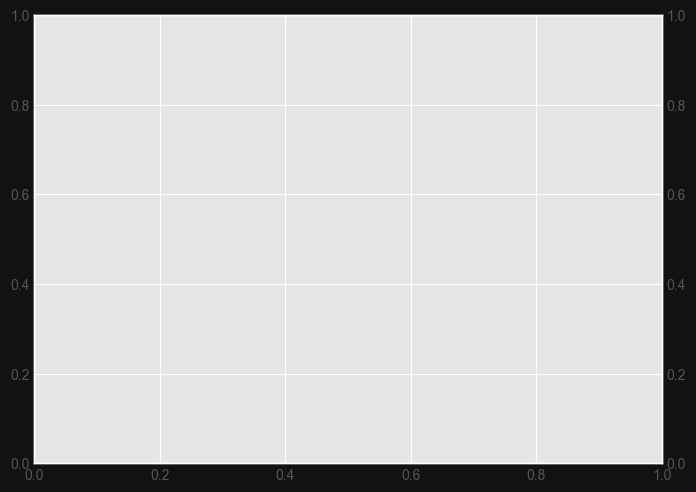

In [39]:
import customtkinter as ctk
from pydantic import BaseModel, Field, PositiveFloat
from typing import Literal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np
import math

# Apply dashboard styling
plt.style.use('ggplot')

class PeckTestConfig(BaseModel):
    """Schema for Peck's THB input validation and conversion."""
    rh_field: PositiveFloat = Field(..., le=100)
    rh_test: PositiveFloat = Field(..., le=100)
    t_max_field_c: float
    t_max_test_c: float
    ea: PositiveFloat = 0.6
    k: PositiveFloat = 8.62e-5
    target_life_value: PositiveFloat
    target_life_unit: Literal["Years", "Months"]

    @property
    def target_life_years(self) -> float:
        """Normalizes user time input to years."""
        return self.target_life_value if self.target_life_unit == "Years" else self.target_life_value / 12.0

    @property
    def t_max_field_k(self) -> float:
        return self.t_max_field_c + 273.15

    @property
    def t_max_test_k(self) -> float:
        return self.t_max_test_c + 273.15


class PeckReliabilityEngine:
    """Calculations and plot data generation for THB."""
    
    @staticmethod
    def calculate_metrics(config: PeckTestConfig) -> dict:
        rh_factor = (config.rh_field / config.rh_test) ** -2.66
        thermal_factor = math.exp(
            (config.ea / config.k) * ((1.0 / config.t_max_field_k) - (1.0 / config.t_max_test_k))
        )
        
        af = rh_factor * thermal_factor
        service_hours = 24 * 365 * config.target_life_years
        test_duration_hours = service_hours / af
        
        return {
            "af": af,
            "service_hours": int(service_hours),
            "test_duration_hours": round(test_duration_hours, 1),
            "test_duration_days": round(test_duration_hours / 24, 1)
        }

    @staticmethod
    def get_steady_state_profile(config: PeckTestConfig, duration_hours: float):
        """Generates timeline data for a steady-state THB profile."""
        # Standard assumption: 1 hour ramp up to steady state
        ramp_time = min(1.0, duration_hours * 0.05) 
        
        t = np.array([0, ramp_time, duration_hours])
        temp = np.array([25.0, config.t_max_test_c, config.t_max_test_c]) # Assuming start at 25C
        rh = np.array([40.0, config.rh_test, config.rh_test])             # Assuming start at 40% RH
        
        return t, temp, rh


class StatCard(ctk.CTkFrame):
    """Reusable metric display."""
    def __init__(self, master, title, value, unit="", color="#1f77b4"):
        super().__init__(master, fg_color="#2b2b2b", corner_radius=8, border_width=1, border_color="#3d3d3d")
        ctk.CTkLabel(self, text=title, font=("Arial", 12), text_color="#aaaaaa").pack(pady=(10, 0))
        self.lbl_val = ctk.CTkLabel(self, text=value, font=("Arial", 22, "bold"), text_color=color)
        self.lbl_val.pack(pady=(2, 2))
        ctk.CTkLabel(self, text=unit, font=("Arial", 10), text_color="#666666").pack(pady=(0, 10))

    def update_val(self, val):
        self.lbl_val.configure(text=str(val))


class PeckApp(ctk.CTk):
    def __init__(self):
        super().__init__()
        self.title("Temperature Humidity Test")
        self.geometry("1200x750")
        ctk.set_appearance_mode("dark")
        
        self.grid_columnconfigure(0, weight=0, minsize=350)
        self.grid_columnconfigure(1, weight=1)
        self.grid_rowconfigure(0, weight=1)

        self.inputs = {}
        self._setup_ui()

    def _setup_ui(self):
        # --- Sidebar ---
        sidebar = ctk.CTkScrollableFrame(self, fg_color="#1a1a1a", corner_radius=0)
        sidebar.grid(row=0, column=0, sticky="nsew")
        
        ctk.CTkLabel(sidebar, text="Temperature Humidity Test", font=("Arial", 18, "bold"), text_color="#e07a5f").pack(pady=20)
        
        groups = [
            ("Field Conditions", [("Humidity (%RH)", "rh_field", "60"), ("Max Temp (°C)", "t_max_field_c", "40")]),
            ("Test Conditions", [("Humidity (%RH)", "rh_test", "85"), ("Max Temp (°C)", "t_max_test_c", "85")]),
            ("Constants", [("Ea (eV)", "ea", "0.6"), ("k (eV/K)", "k", "8.62e-05")])
        ]

        for name, fields in groups:
            ctk.CTkLabel(sidebar, text=name, font=("Arial", 12, "bold"), text_color="#555555").pack(anchor="w", padx=20, pady=(10, 2))
            for label, key, default in fields:
                f = ctk.CTkFrame(sidebar, fg_color="transparent")
                f.pack(fill="x", padx=20, pady=2)
                ctk.CTkLabel(f, text=label, width=120, anchor="w").pack(side="left")
                entry = ctk.CTkEntry(f, height=28)
                entry.insert(0, default)
                entry.pack(side="right", fill="x", expand=True)
                self.inputs[key] = entry

        # Target Life with Dropdown
        ctk.CTkLabel(sidebar, text="Life Requirement", font=("Arial", 12, "bold"), text_color="#555555").pack(anchor="w", padx=20, pady=(15, 2))
        life_f = ctk.CTkFrame(sidebar, fg_color="transparent")
        life_f.pack(fill="x", padx=20)
        
        self.life_val = ctk.CTkEntry(life_f, width=80)
        self.life_val.insert(0, "10")
        self.life_val.pack(side="left")
        
        self.life_unit = ctk.CTkOptionMenu(life_f, values=["Years", "Months"], height=28)
        self.life_unit.pack(side="right", fill="x", expand=True, padx=(5, 0))

        self.btn = ctk.CTkButton(sidebar, text="CALCULATE & PLOT", command=self.run, fg_color="#e07a5f", hover_color="#c86247", height=40)
        self.btn.pack(pady=30, padx=20, fill="x")
        self.error_lbl = ctk.CTkLabel(sidebar, text="", text_color="#ff4d4d")
        self.error_lbl.pack()

        # --- Main Content ---
        main = ctk.CTkFrame(self, fg_color="#121212", corner_radius=0)
        main.grid(row=0, column=1, sticky="nsew")

        # Stats
        stat_f = ctk.CTkFrame(main, fg_color="transparent")
        stat_f.pack(fill="x", padx=20, pady=20)
        
        self.cards = {
            "af": StatCard(stat_f, "Acceleration (AF)", "-", "Multiplier", "#ff9f1c"),
            "svc": StatCard(stat_f, "Service Hours", "-", "Required", "#2ec4b6"),
            "test_hr": StatCard(stat_f, "Test Hours", "-", "Duration", "#e71d36"),
            "test_day": StatCard(stat_f, "Test Days", "-", "Duration", "#e71d36")
        }
        for card in self.cards.values():
            card.pack(side="left", fill="both", expand=True, padx=5)

        # Plot
        self.fig, self.ax1 = plt.subplots(figsize=(8, 4), facecolor='#121212')
        self.ax2 = self.ax1.twinx() # Dual axis for RH%
        self.canvas = FigureCanvasTkAgg(self.fig, master=main)
        self.canvas.get_tk_widget().pack(fill="both", expand=True, padx=20, pady=10)

    def _update_plot(self, t, temp, rh):
        """Renders a polished, high-contrast dual-axis plot."""
        self.ax1.clear()
        self.ax2.clear()
        
        # 1. Background Styling
        self.ax1.set_facecolor('#121212')
        self.fig.patch.set_facecolor('#121212')

        # 2. High-Visibility Colors for Dark Mode
        color_temp = "#ff4d4d" # Bright Pastel Red
        color_rh = "#00ffff"   # Bright Cyan

        # 3. Plot Temperature (Left Axis)
        l1 = self.ax1.plot(t, temp, color=color_temp, linewidth=2.5, label="Temperature (°C)")
        self.ax1.fill_between(t, temp, 0, color=color_temp, alpha=0.15) # Shading to 0 for solid grounding
        self.ax1.set_ylabel("Temperature (°C)", color=color_temp, fontsize=12, labelpad=15, fontweight='bold')
        self.ax1.tick_params(axis='y', colors=color_temp, labelsize=11)
        
        # Add headroom so lines don't hit the absolute top of the frame
        max_temp = max(temp) if len(temp) > 0 else 100
        self.ax1.set_ylim(0, max_temp * 1.2) 

        # 4. Plot Humidity (Right Axis)
        l2 = self.ax2.plot(t, rh, color=color_rh, linewidth=2.5, linestyle="--", label="Humidity (%RH)")
        self.ax2.set_ylabel("Relative Humidity (%)", color=color_rh, fontsize=12, labelpad=20, fontweight='bold')
        self.ax2.tick_params(axis='y', colors=color_rh, labelsize=11)
        self.ax2.set_ylim(0, 105) # RH is naturally capped near 100, lock the scale for consistency

        # 5. Fix Overlapping Grids
        # CRITICAL: Only the primary axis gets a grid. We make it subtle.
        self.ax1.grid(True, color='#333333', linestyle='-', linewidth=0.5)
        self.ax2.grid(False) 

        # 6. X-Axis Styling
        self.ax1.set_xlabel("Test Duration (Hours)", color="#cccccc", fontsize=12, labelpad=10)
        self.ax1.tick_params(axis='x', colors="#cccccc", labelsize=11)

        # 7. Clean up borders (spines)
        for spine in self.ax1.spines.values():
            spine.set_color('#333333')
            spine.set_linewidth(1.5)
        for spine in self.ax2.spines.values():
            spine.set_color('#333333')
            spine.set_linewidth(1.5)
            
        # 8. Unified Legend
        # Combine handles from both axes into a single clean box
        lines = l1 + l2
        labels = [l.get_label() for l in lines]
        self.ax1.legend(lines, labels, loc='lower right', frameon=True, 
                        facecolor='#1a1a1a', edgecolor='#333333', labelcolor='white')

        # 9. Final Layout Adjustments
        self.ax1.set_title("Steady-State THB Profile", color="white", pad=20, fontsize=14, fontweight='bold')
        self.fig.tight_layout() # This will now respect the labelpads
        self.canvas.draw()

    def run(self):
        self.error_lbl.configure(text="")
        try:
            data = {k: v.get() for k, v in self.inputs.items()}
            data.update({"target_life_value": self.life_val.get(), "target_life_unit": self.life_unit.get()})
            config = PeckTestConfig(**data)
            
            metrics = PeckReliabilityEngine.calculate_metrics(config)
            t, temp, rh = PeckReliabilityEngine.get_steady_state_profile(config, metrics['test_duration_hours'])
            
            self.cards["af"].update_val(f"{metrics['af']:,.2f}x")
            self.cards["svc"].update_val(f"{metrics['service_hours']:,}")
            self.cards["test_hr"].update_val(f"{metrics['test_duration_hours']:,.1f}")
            self.cards["test_day"].update_val(f"{metrics['test_duration_days']:,.1f}")
            
            self._update_plot(t, temp, rh)
        except Exception as e:
            self.error_lbl.configure(text="Invalid Input: Ensure all fields are numeric.")
            print(f"Engine Error: {e}")

if __name__ == "__main__":
    app = PeckApp()
    app.mainloop()

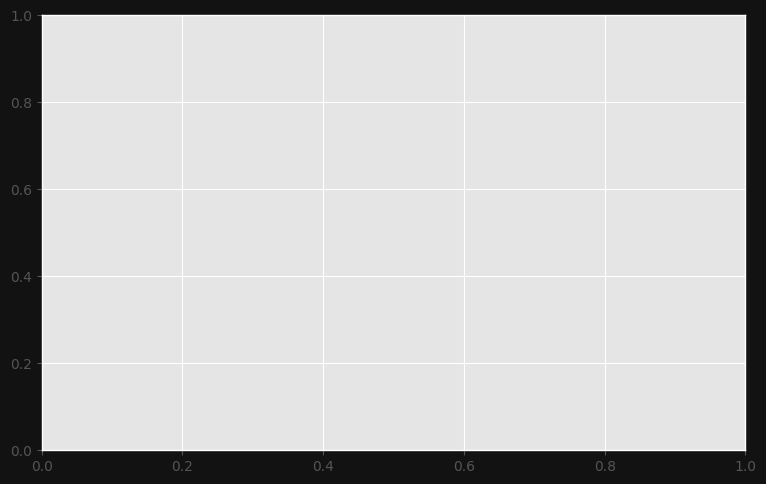

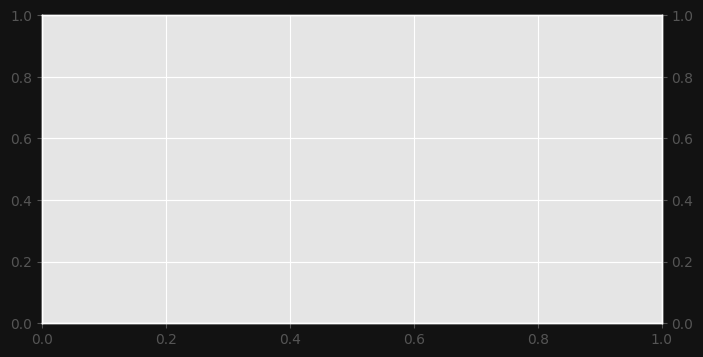

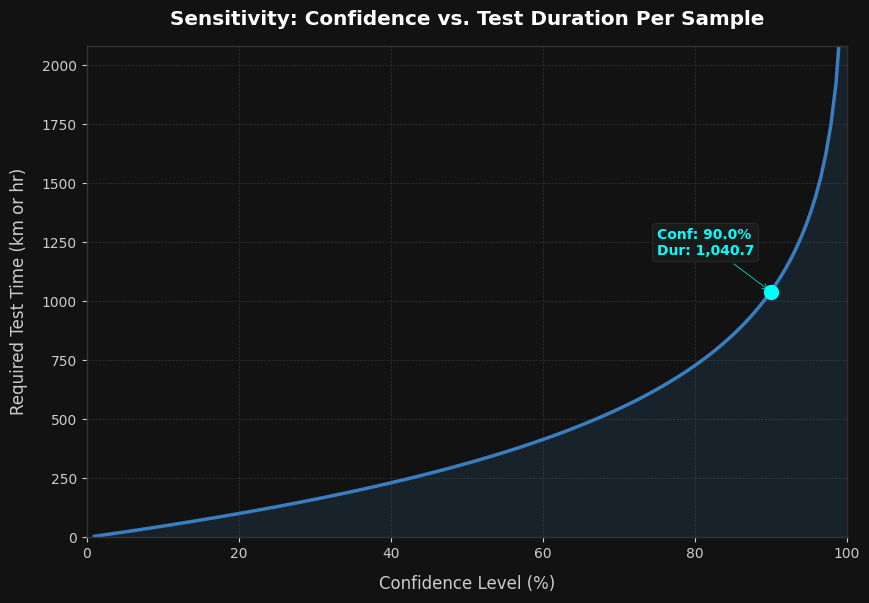

In [1]:
import customtkinter as ctk
from pydantic import BaseModel, Field, PositiveFloat, PositiveInt
from typing import Literal
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np
import math
from scipy.stats import chi2

# ==========================================
# GLOBAL STYLING & COMPONENTS
# ==========================================
plt.style.use('ggplot')

class StatCard(ctk.CTkFrame):
    """A reusable component for attractive metric display across all tabs."""
    def __init__(self, master, title, value, unit="", color="#1f77b4"):
        super().__init__(master, fg_color="#2b2b2b", corner_radius=10, border_width=1, border_color="#3d3d3d")
        self.lbl_title = ctk.CTkLabel(self, text=title, font=("Arial", 12), text_color="#aaaaaa")
        self.lbl_title.pack(pady=(10, 0))
        self.lbl_val = ctk.CTkLabel(self, text=value, font=("Arial", 22, "bold"), text_color=color)
        self.lbl_val.pack(pady=(0, 5))
        self.lbl_unit = ctk.CTkLabel(self, text=unit, font=("Arial", 10), text_color="#666666")
        self.lbl_unit.pack(pady=(0, 10))

    def update_val(self, val):
        self.lbl_val.configure(text=str(val))


# ==========================================
# MODULE 1: THERMAL AGING (COFFIN-MANSON)
# ==========================================
class ThermalConfig(BaseModel):
    t_min_use: float
    t_max_use: float
    t_min_test: float
    t_max_test: float
    dwell_max_hr: float = Field(ge=0)
    dwell_min_hr: float = Field(ge=0)
    ramp_up_rate: PositiveFloat
    ramp_down_rate: PositiveFloat
    m_exponent: PositiveFloat
    time_value: PositiveFloat
    time_unit: Literal["Years", "Months", "Days"]
    cycles_per_day: PositiveFloat

    @property
    def time_in_years(self) -> float:
        multipliers = {"Years": 1.0, "Months": 1/12, "Days": 1/365}
        return self.time_value * multipliers[self.time_unit]

class ThermalEngine:
    @staticmethod
    def calculate_metrics(config: ThermalConfig) -> dict:
        delta_t_use = config.t_max_use - config.t_min_use
        delta_t_test = config.t_max_test - config.t_min_test
        af = (delta_t_test / delta_t_use) ** config.m_exponent
        
        cycles_field = config.time_in_years * 365 * config.cycles_per_day
        cycles_test = cycles_field / af
        
        r_up = (delta_t_test / config.ramp_up_rate) / 60
        r_down = (delta_t_test / config.ramp_down_rate) / 60
        total_hr = (config.dwell_max_hr + config.dwell_min_hr + r_up + r_down) * cycles_test
        
        return {
            "af": af,
            "cycles_field": int(cycles_field),
            "cycles_test": int(cycles_test),
            "total_hr": round(total_hr, 1),
            "total_days": round(total_hr / 24, 1)
        }

    @staticmethod
    def get_plot_data(config: ThermalConfig, mode: str, cycles_test: int):
        delta_t = config.t_max_test - config.t_min_test
        r_up = (delta_t / config.ramp_up_rate)
        d_max = config.dwell_max_hr * 60
        r_down = (delta_t / config.ramp_down_rate)
        d_min = config.dwell_min_hr * 60
        
        single_t = np.array([0, r_up, r_up + d_max, r_up + d_max + r_down, r_up + d_max + r_down + d_min])
        single_temp = np.array([config.t_min_test, config.t_max_test, config.t_max_test, config.t_min_test, config.t_min_test])
        
        if mode == "Single Cycle":
            return single_t, single_temp
        else:
            num_show = min(5, int(cycles_test))
            full_t, full_temp = [], []
            for i in range(num_show):
                full_t.extend(single_t + (i * single_t[-1]))
                full_temp.extend(single_temp)
            return np.array(full_t), np.array(full_temp)

class ThermalTab(ctk.CTkFrame):
    def __init__(self, master):
        super().__init__(master, fg_color="transparent")
        self.grid_columnconfigure(0, weight=0, minsize=320)
        self.grid_columnconfigure(1, weight=1)
        self.grid_rowconfigure(0, weight=1)
        self.inputs = {}
        self._setup_ui()

    def _setup_ui(self):
        sidebar = ctk.CTkScrollableFrame(self, fg_color="#1a1a1a", corner_radius=0)
        sidebar.grid(row=0, column=0, sticky="nsew")
        ctk.CTkLabel(sidebar, text="THERMAL AGING", font=("Arial", 20, "bold"), text_color="#3a7ebf").pack(pady=20)
        
        groups = [
            ("Field Environment", [("Tmin (Field)", "t_min_use", "25"), ("Tmax (Field)", "t_max_use", "85")]),
            ("Test Profile", [("Tmin (test)", "t_min_test", "10"), ("Tmax (test)", "t_max_test", "80"), 
                              ("Ramp Up (°C/min)", "ramp_up_rate", "3"), ("RampDown (°C/min)", "ramp_down_rate", "3")]),
            ("Dwell Settings", [("Dwell Max (Hr)", "dwell_max_hr", "1"), ("Dwell Min (Hr)", "dwell_min_hr", "1")]),
            ("Parameters", [("m exponent", "m_exponent", "3"), ("Cycles/Day", "cycles_per_day", "1")])
        ]
        for name, fields in groups:
            ctk.CTkLabel(sidebar, text=name, font=("Arial", 12, "bold"), text_color="#555555").pack(anchor="w", padx=20, pady=(15, 5))
            for label, key, default in fields:
                f = ctk.CTkFrame(sidebar, fg_color="transparent")
                f.pack(fill="x", padx=20)
                ctk.CTkLabel(f, text=label, width=120, anchor="w").pack(side="left")
                entry = ctk.CTkEntry(f, height=28)
                entry.insert(0, default) 
                entry.pack(side="right", fill="x", expand=True, pady=2)
                self.inputs[key] = entry

        ctk.CTkLabel(sidebar, text="Life Requirement", font=("Arial", 12, "bold"), text_color="#555555").pack(anchor="w", padx=20, pady=(15, 5))
        dur_f = ctk.CTkFrame(sidebar, fg_color="transparent")
        dur_f.pack(fill="x", padx=20)
        self.time_val = ctk.CTkEntry(dur_f, width=80)
        self.time_val.insert(0, "5")
        self.time_val.pack(side="left")
        self.time_unit = ctk.CTkOptionMenu(dur_f, values=["Years", "Months", "Days"], height=28)
        self.time_unit.set("Years")
        self.time_unit.pack(side="right", fill="x", expand=True, padx=(5, 0))

        ctk.CTkButton(sidebar, text="RUN ANALYSIS", command=self.run, fg_color="#3a7ebf", hover_color="#2d6194", height=40).pack(pady=30, padx=20, fill="x")
        self.error_lbl = ctk.CTkLabel(sidebar, text="", text_color="#ff4d4d")
        self.error_lbl.pack()

        main = ctk.CTkFrame(self, fg_color="#121212", corner_radius=0)
        main.grid(row=0, column=1, sticky="nsew")

        stats_row = ctk.CTkFrame(main, fg_color="transparent")
        stats_row.pack(fill="x", padx=20, pady=20)
        self.cards = {
            "af": StatCard(stats_row, "Acceleration Factor", "-", "AF Ratio", "#3a7ebf"),
            "field": StatCard(stats_row, "Field Cycles", "-", "Required", "#3a7ebf"),
            "test": StatCard(stats_row, "Test Cycles", "-", "Simulated", "#3a7ebf"),
            "days": StatCard(stats_row, "Total Duration", "-", "Days", "#4cd964")
        }
        for card in self.cards.values(): card.pack(side="left", fill="both", expand=True, padx=5)

        ctrl_f = ctk.CTkFrame(main, fg_color="transparent")
        ctrl_f.pack(fill="x", padx=25)
        self.view_mode = ctk.CTkSegmentedButton(ctrl_f, values=["Single Cycle", "Complete View"], command=lambda _: self.run())
        self.view_mode.set("Single Cycle")
        self.view_mode.pack(side="right")

        self.fig, self.ax = plt.subplots(figsize=(8, 4), facecolor='#121212')
        self.canvas = FigureCanvasTkAgg(self.fig, master=main)
        self.canvas.get_tk_widget().pack(fill="both", expand=True, padx=20, pady=20)

    def run(self):
        self.error_lbl.configure(text="")
        try:
            data = {k: v.get() for k, v in self.inputs.items()}
            data.update({"time_value": self.time_val.get(), "time_unit": self.time_unit.get()})
            config = ThermalConfig(**data)
            metrics = ThermalEngine.calculate_metrics(config)
            
            self.cards["af"].update_val(f"{metrics['af']:.2f}x")
            self.cards["field"].update_val(f"{metrics['cycles_field']:,}")
            self.cards["test"].update_val(f"{metrics['cycles_test']:,}")
            self.cards["days"].update_val(f"{metrics['total_days']:,}")

            t, temp = ThermalEngine.get_plot_data(config, self.view_mode.get(), metrics['cycles_test'])
            self.ax.clear()
            self.ax.set_facecolor('#121212')
            self.ax.plot(t, temp, color="#3a7ebf", linewidth=2, marker='o' if "Single" in self.view_mode.get() else None)
            self.ax.fill_between(t, temp, min(temp)-10, color="#3a7ebf", alpha=0.2)
            self.ax.set_title(f"Thermal Profile: {self.view_mode.get()}", color="white", pad=15)
            self.ax.set_xlabel("Time (Minutes)", color="#cccccc")
            self.ax.set_ylabel("Temp (°C)", color="#cccccc")
            self.ax.tick_params(colors="#cccccc")
            for spine in self.ax.spines.values(): spine.set_color('#333333')
            self.fig.tight_layout()
            self.canvas.draw()
        except Exception as e:
            self.error_lbl.configure(text="Invalid Input Data.")


# ==========================================
# MODULE 2: TEMPERATURE HUMIDITY (THB)
# ==========================================
class THBConfig(BaseModel):
    rh_field: PositiveFloat = Field(..., le=100)
    rh_test: PositiveFloat = Field(..., le=100)
    t_max_field_c: float
    t_max_test_c: float
    ea: PositiveFloat = 0.6
    k: PositiveFloat = 8.62e-5
    target_life_value: PositiveFloat
    target_life_unit: Literal["Years", "Months"]

    @property
    def target_life_years(self) -> float:
        return self.target_life_value if self.target_life_unit == "Years" else self.target_life_value / 12.0

    @property
    def t_max_field_k(self) -> float: return self.t_max_field_c + 273.15
    @property
    def t_max_test_k(self) -> float: return self.t_max_test_c + 273.15

class THBEngine:
    @staticmethod
    def calculate_metrics(config: THBConfig) -> dict:
        rh_factor = (config.rh_field / config.rh_test) ** -2.66
        thermal_factor = math.exp((config.ea / config.k) * ((1.0 / config.t_max_field_k) - (1.0 / config.t_max_test_k)))
        af = rh_factor * thermal_factor
        service_hours = 24 * 365 * config.target_life_years
        test_duration_hours = service_hours / af
        return {
            "af": af, "service_hours": int(service_hours),
            "test_duration_hours": round(test_duration_hours, 1),
            "test_duration_days": round(test_duration_hours / 24, 1)
        }

    @staticmethod
    def get_steady_state_profile(config: THBConfig, duration_hours: float):
        ramp_time = min(1.0, duration_hours * 0.05) 
        t = np.array([0, ramp_time, duration_hours])
        temp = np.array([25.0, config.t_max_test_c, config.t_max_test_c])
        rh = np.array([40.0, config.rh_test, config.rh_test])
        return t, temp, rh

class THBTab(ctk.CTkFrame):
    def __init__(self, master):
        super().__init__(master, fg_color="transparent")
        self.grid_columnconfigure(0, weight=0, minsize=320)
        self.grid_columnconfigure(1, weight=1)
        self.grid_rowconfigure(0, weight=1)
        self.inputs = {}
        self._setup_ui()

    def _setup_ui(self):
        sidebar = ctk.CTkScrollableFrame(self, fg_color="#1a1a1a", corner_radius=0)
        sidebar.grid(row=0, column=0, sticky="nsew")
        ctk.CTkLabel(sidebar, text="TEMPERATURE HUMIDITY", font=("Arial", 18, "bold"), text_color="#3a7ebf").pack(pady=20)
        
        groups = [
            ("Field Conditions", [("Humidity (%RH)", "rh_field", "60"), ("Max Temp (°C)", "t_max_field_c", "40")]),
            ("Test Conditions", [("Humidity (%RH)", "rh_test", "85"), ("Max Temp (°C)", "t_max_test_c", "85")]),
            ("Constants", [("Ea (eV)", "ea", "0.6"), ("k (eV/K)", "k", "8.62e-05")])
        ]
        for name, fields in groups:
            ctk.CTkLabel(sidebar, text=name, font=("Arial", 12, "bold"), text_color="#555555").pack(anchor="w", padx=20, pady=(10, 2))
            for label, key, default in fields:
                f = ctk.CTkFrame(sidebar, fg_color="transparent")
                f.pack(fill="x", padx=20, pady=2)
                ctk.CTkLabel(f, text=label, width=120, anchor="w").pack(side="left")
                entry = ctk.CTkEntry(f, height=28)
                entry.insert(0, default)
                entry.pack(side="right", fill="x", expand=True)
                self.inputs[key] = entry

        ctk.CTkLabel(sidebar, text="Life Requirement", font=("Arial", 12, "bold"), text_color="#555555").pack(anchor="w", padx=20, pady=(15, 2))
        life_f = ctk.CTkFrame(sidebar, fg_color="transparent")
        life_f.pack(fill="x", padx=20)
        self.life_val = ctk.CTkEntry(life_f, width=80)
        self.life_val.insert(0, "10")
        self.life_val.pack(side="left")
        self.life_unit = ctk.CTkOptionMenu(life_f, values=["Years", "Months"], height=28)
        self.life_unit.pack(side="right", fill="x", expand=True, padx=(5, 0))

        ctk.CTkButton(sidebar, text="CALCULATE & PLOT", command=self.run, fg_color="#3a7ebf", hover_color="#2d6194", height=40).pack(pady=30, padx=20, fill="x")
        self.error_lbl = ctk.CTkLabel(sidebar, text="", text_color="#ff4d4d")
        self.error_lbl.pack()

        main = ctk.CTkFrame(self, fg_color="#121212", corner_radius=0)
        main.grid(row=0, column=1, sticky="nsew")

        stat_f = ctk.CTkFrame(main, fg_color="transparent")
        stat_f.pack(fill="x", padx=20, pady=20)
        self.cards = {
            "af": StatCard(stat_f, "Acceleration (AF)", "-", "Multiplier", "#3a7ebf"),
            "svc": StatCard(stat_f, "Service Hours", "-", "Required", "#3a7ebf"),
            "test_hr": StatCard(stat_f, "Test Hours", "-", "Duration", "#3a7ebf"),
            "test_day": StatCard(stat_f, "Test Days", "-", "Duration", "#4cd964")
        }
        for card in self.cards.values(): card.pack(side="left", fill="both", expand=True, padx=5)

        self.fig, self.ax1 = plt.subplots(figsize=(8, 4), facecolor='#121212')
        self.ax2 = self.ax1.twinx()
        self.canvas = FigureCanvasTkAgg(self.fig, master=main)
        self.canvas.get_tk_widget().pack(fill="both", expand=True, padx=20, pady=10)

    def run(self):
        self.error_lbl.configure(text="")
        try:
            data = {k: v.get() for k, v in self.inputs.items()}
            data.update({"target_life_value": self.life_val.get(), "target_life_unit": self.life_unit.get()})
            config = THBConfig(**data)
            
            metrics = THBEngine.calculate_metrics(config)
            t, temp, rh = THBEngine.get_steady_state_profile(config, metrics['test_duration_hours'])
            
            self.cards["af"].update_val(f"{metrics['af']:,.2f}x")
            self.cards["svc"].update_val(f"{metrics['service_hours']:,}")
            self.cards["test_hr"].update_val(f"{metrics['test_duration_hours']:,.1f}")
            self.cards["test_day"].update_val(f"{metrics['test_duration_days']:,.1f}")
            
            self.ax1.clear()
            self.ax2.clear()
            self.ax1.set_facecolor('#121212')
            self.fig.patch.set_facecolor('#121212')

            c_temp, c_rh = "#3a7ebf", "#00ffff"
            l1 = self.ax1.plot(t, temp, color=c_temp, linewidth=2.5, label="Temperature (°C)")
            self.ax1.fill_between(t, temp, 0, color=c_temp, alpha=0.15)
            self.ax1.set_ylabel("Temperature (°C)", color=c_temp, fontsize=12, labelpad=15)
            self.ax1.set_ylim(0, max(temp) * 1.2 if len(temp)>0 else 100) 

            l2 = self.ax2.plot(t, rh, color=c_rh, linewidth=2.5, linestyle="--", label="Humidity (%RH)")
            self.ax2.set_ylabel("Relative Humidity (%)", color=c_rh, fontsize=12, labelpad=20)
            self.ax2.set_ylim(0, 105)

            self.ax1.grid(True, color='#333333', linestyle='-', linewidth=0.5)
            self.ax2.grid(False) 
            self.ax1.set_xlabel("Test Duration (Hours)", color="#cccccc", fontsize=12, labelpad=10)
            self.ax1.tick_params(axis='x', colors="white")
            self.ax1.tick_params(axis='y', colors=c_temp)
            self.ax2.tick_params(axis='y', colors=c_rh)

            for spine in self.ax1.spines.values(): spine.set_color('#333333')
            for spine in self.ax2.spines.values(): spine.set_color('#333333')
            
            self.ax1.legend(l1+l2, [l.get_label() for l in l1+l2], loc='lower right', frameon=True, facecolor='#1a1a1a', labelcolor='white')
            self.ax1.set_title("Steady-State THB Profile", color="white", pad=20, fontsize=14, fontweight='bold')
            self.fig.tight_layout()
            self.canvas.draw()
        except Exception as e:
            self.error_lbl.configure(text="Invalid Input Data.")


# ==========================================
# MODULE 3: RELIABILITY DEMONSTRATION TESTING
# ==========================================
class DemoConfig(BaseModel):
    mtbf: PositiveFloat
    target_rel: float = Field(..., gt=0, lt=1, description="Target Reliability (R)")
    conf: float = Field(..., gt=0, lt=1, description="Confidence (C)")
    sample_size: PositiveInt = Field(..., description="Sample Size (n)")
    failures: int = Field(..., ge=0, description="Allowed Failures (x)")

class DemoEngine:
    @staticmethod
    def calculate_metrics(config: DemoConfig) -> dict:
        C = config.conf
        R = config.target_rel
        n = config.sample_size
        x = config.failures
        mtbf = config.mtbf

        # Base time calculation
        base_time = (mtbf * math.log(1.0 - C)) / (math.log(R) * n)

        if x == 0:
            test_time_per_unit = base_time
            chi_val = 0.0 # N/A for 0 failures
        else:
            chi_val = chi2.ppf(C, 2 * x + 2)
            multiplier = chi_val / (-2.0 * math.log(1.0 - C))
            test_time_per_unit = base_time * multiplier

        return {
            "test_time": test_time_per_unit, 
            "base_time": base_time,
            "chi_val": chi_val
        }

    @staticmethod
    def generate_curve_data(config: DemoConfig) -> tuple[np.ndarray, np.ndarray]:
        conf_range = np.linspace(0.01, 0.999, 150)
        R = config.target_rel
        n = config.sample_size
        x = config.failures
        mtbf = config.mtbf
        
        times = []
        for C in conf_range:
            base = (mtbf * math.log(1.0 - C)) / (math.log(R) * n)
            if x == 0:
                times.append(base)
            else:
                chi_v = chi2.ppf(C, 2 * x + 2)
                times.append(base * (chi_v / (-2.0 * math.log(1.0 - C))))
                
        return conf_range * 100, np.array(times)

class WeibullTab(ctk.CTkFrame):
    def __init__(self, master):
        super().__init__(master, fg_color="transparent")
        self.grid_columnconfigure(0, weight=0, minsize=320)
        self.grid_columnconfigure(1, weight=1)
        self.grid_rowconfigure(0, weight=1)
        self.inputs = {}
        self._setup_ui()
        self.run()

    def _setup_ui(self):
        sidebar = ctk.CTkFrame(self, fg_color="#1a1a1a", corner_radius=0)
        sidebar.grid(row=0, column=0, sticky="nsew")
        ctk.CTkLabel(sidebar, text="TEST DURATION PLANNER", font=("Arial", 18, "bold"), text_color="#3a7ebf").pack(pady=20)
        
        fields = [
            ("Target MTBF (km/hr)", "mtbf", "1000"), 
            ("Target Reliability (0.01-0.99)", "target_rel", "0.90"),
            ("Confidence C (0.01-0.99)", "conf", "0.90"), 
            ("Sample Size n (Units)", "sample_size", "2"),
            ("Allowed Failures x", "failures", "0")
        ]
        
        for label, key, default in fields:
            f = ctk.CTkFrame(sidebar, fg_color="transparent")
            f.pack(fill="x", padx=20, pady=10)
            ctk.CTkLabel(f, text=label, width=150, anchor="w").pack(side="left")
            entry = ctk.CTkEntry(f, height=28)
            entry.insert(0, default)
            entry.pack(side="right", fill="x", expand=True)
            self.inputs[key] = entry

        ctk.CTkButton(sidebar, text="CALCULATE PLAN", command=self.run, fg_color="#3a7ebf", hover_color="#2d6194", height=45).pack(pady=30, padx=20, fill="x")
        self.error_lbl = ctk.CTkLabel(sidebar, text="", text_color="#ff4d4d")
        self.error_lbl.pack(padx=20)

        main = ctk.CTkFrame(self, fg_color="#121212", corner_radius=0)
        main.grid(row=0, column=1, sticky="nsew")

        cards_frame = ctk.CTkFrame(main, fg_color="transparent")
        cards_frame.pack(fill="x", padx=20, pady=20)
        self.cards = {
            "time": StatCard(cards_frame, "Test Time Per Unit", "-", "km or hr", "#4cd964"),
            "base": StatCard(cards_frame, "Base Time (0 Failures)", "-", "km or hr", "#4cd964")
        }
        for card in self.cards.values(): card.pack(side="left", fill="both", expand=True, padx=5)

        self.fig, self.ax = plt.subplots(figsize=(8, 4), facecolor='#121212')
        self.canvas = FigureCanvasTkAgg(self.fig, master=main)
        self.canvas.get_tk_widget().pack(fill="both", expand=True, padx=25, pady=10)

    def run(self):
        self.error_lbl.configure(text="")
        try:
            data = {k: v.get() for k, v in self.inputs.items()}
            config = DemoConfig(**data)
            
            metrics = DemoEngine.calculate_metrics(config)
            conf_x, time_y = DemoEngine.generate_curve_data(config)
            
            self.cards["time"].update_val(f"{metrics['test_time']:,.1f}")
            self.cards["base"].update_val(f"{metrics['base_time']:,.1f}")

            self.ax.clear()
            self.ax.set_facecolor('#121212')
            line_color, hl_color = "#3a7ebf", "#00ffff"
            
            self.ax.plot(conf_x, time_y, color=line_color, linewidth=2.5)
            self.ax.fill_between(conf_x, time_y, min(time_y)*0.9, color=line_color, alpha=0.15)
            
            t_conf, t_time = config.conf * 100, metrics['test_time']
            self.ax.plot(t_conf, t_time, marker='o', markersize=10, color=hl_color)
            self.ax.annotate(f"Conf: {t_conf:.1f}%\nDur: {t_time:,.1f}", xy=(t_conf, t_time), 
                             xytext=(t_conf - 15, t_time * 1.15), color=hl_color, weight="bold",
                             arrowprops=dict(arrowstyle="->", color=hl_color),
                             bbox=dict(boxstyle="round,pad=0.3", fc="#1a1a1a", ec="#333333"))

            self.ax.set_title("Sensitivity: Confidence vs. Test Duration Per Sample", color="white", pad=15, fontweight="bold")
            self.ax.set_xlabel("Confidence Level (%)", color="#cccccc", labelpad=10)
            self.ax.set_ylabel("Required Test Time (km or hr)", color="#cccccc", labelpad=10)
            
            self.ax.set_xlim(0, 100)
            self.ax.set_ylim(0, max(t_time * 2.0, np.percentile(time_y, 95)))
            
            self.ax.tick_params(colors="#cccccc")
            self.ax.grid(True, color='#333333', linestyle='--', linewidth=0.5)
            for spine in self.ax.spines.values(): spine.set_color('#333333')
            
            self.fig.tight_layout()
            self.canvas.draw()
            
        except Exception as e:
            self.error_lbl.configure(text="Invalid Input Data.")


# ==========================================
# MAIN APPLICATION CONTROLLER
# ==========================================
class ReliabilityDesignStudio(ctk.CTk):
    def __init__(self):
        super().__init__()
        self.title("Reliapp")
        self.geometry("1300x850")
        ctk.set_appearance_mode("dark")

        # Create TabView
        self.tabview = ctk.CTkTabview(self)
        self.tabview.pack(fill="both", expand=True, padx=10, pady=10)
        
        # Add Tabs
        tab_thermal = self.tabview.add("Thermal Cycle (Coffin-Manson)")
        tab_thb = self.tabview.add("Temperature-Humidity (Peck)")
        tab_weibull = self.tabview.add("Demonstration (Weibull)")

        # Inject Encapsulated Modules into Tabs
        self.thermal_module = ThermalTab(tab_thermal)
        self.thermal_module.pack(fill="both", expand=True)

        self.thb_module = THBTab(tab_thb)
        self.thb_module.pack(fill="both", expand=True)

        self.weibull_module = WeibullTab(tab_weibull)
        self.weibull_module.pack(fill="both", expand=True)

if __name__ == "__main__":
    app = ReliabilityDesignStudio()
    app.mainloop()